# 5. Spindulio tipo bazinių funkcijų (RBF) tinklas

**Failas:** `winequality/rbf.py` — `hidden_activations`, `ridge_output_weights`, `predict_from_rbf`, `RBFNetwork`  
**Mokymas:** `winequality/tune.py` → `tune_rbf`

LD3 metodas. Konceptualiai tai SVR–RBF su **fiksuotais** centrais (k-vidurkiai), todėl
plane jis ir abliacija: kiek vertės duoda adaptyvus atraminių vektorių parinkimas.


## Formulės

Centrai \(\mathbf{c}_k\) — k-vidurkių klasterių centrai. Plotis — vidutinis atstumas
iki kaimyninių centrų. Paslėpto sluoksnio aktyvacijos:

\[
\varphi_k(\mathbf{z}) = \exp\left(-\frac{\|\mathbf{z}-\mathbf{c}_k\|^2}{2\sigma_k^2}\right)
\]

Išėjimas ir uždara L2 (ridge) formulė (poslinkiui \(b\) bauda netaikoma):

\[
f(\mathbf{z}) = \sum_{k=1}^{K} w_k\,\varphi_k(\mathbf{z}) + b,\qquad
\mathbf{w} = (\Phi^\top\Phi + \lambda I)^{-1}\Phi^\top \mathbf{y}
\]


In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
root = here if (here / "winequality").exists() else here.parent
sys.path.insert(0, str(root))
sys.path.insert(0, str(root / "notebooks"))

from nb_pagalba import paruošti, metrikos_lentele, artefaktas
from winequality.config import FEATURE_NAMES, SPLIT_SEED

KIND = "red"  # pakeiskite į "white", jei norite balto vyno
duom = paruošti(KIND)
X_tr, y_tr, X_te, y_te = duom["X_tr"], duom["y_tr"], duom["X_te"], duom["y_te"]
print(f"{KIND}: mokymo n={duom['n_train']}, testo n={duom['n_test']}, sėkla={SPLIT_SEED}")
print("Požymiai:", FEATURE_NAMES)


red: mokymo n=1279, testo n=320, sėkla=0
Požymiai: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## Artefaktas arba demonstracinis RBF tinklas


In [2]:
import joblib
from winequality.rbf import (
    hidden_activations, predict_from_rbf, rbf_pipeline,
)

kelias = artefaktas("rbf", KIND)
if kelias.exists():
    vamzdis = joblib.load(kelias)
    print("Įkeltas artefaktas:", kelias.name)
else:
    print("Artefakto nėra — mokomas RBF tinklas su K=40.")
    vamzdis = rbf_pipeline(n_centers=40, ridge=0.01, seed=0)
    vamzdis.fit(X_tr, y_tr)

net = vamzdis.named_steps["rbf"]
print("K =", net.centres_.shape[0], "  ridge =", net.ridge)
print("σ intervalas:", float(net.widths_.min()), "…", float(net.widths_.max()))


Įkeltas artefaktas: rbf_red.joblib
K = 80   ridge = 0.23826650493636628
σ intervalas: 1.3596989878661616 … 4.808064229921285


## Formulės kelias = `.predict`


φ forma (mėginiai × centrai): (320, 80)
φ rėžiai: [ 3.038593386312671e-26 , 0.9636326304497368 ]  (turi būti (0, 1])
max |formulė − predict| = 0.0


,modelis,MAE,MAE (apvalinta),Acc_0.5,Acc_1.0,κ_w,makro-F1
0,RBF tinklas,0.4973,0.3969,0.6281,0.875,0.589,0.5468


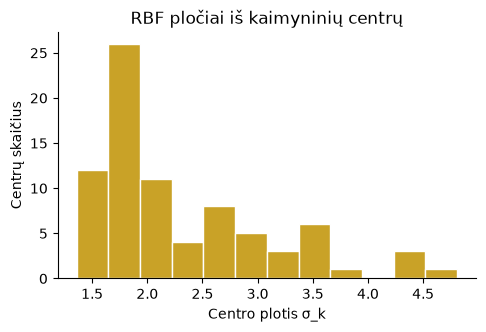

In [3]:
z_te = vamzdis.named_steps["prep"].transform(X_te)
phi = hidden_activations(z_te, net.centres_, net.widths_)
f_formule = predict_from_rbf(z_te, net.centres_, net.widths_, net.weights_)
f_api = vamzdis.predict(X_te)
print("φ forma (mėginiai × centrai):", phi.shape)
print("φ rėžiai: [", phi.min(), ",", phi.max(), "]  (turi būti (0, 1])")
print("max |formulė − predict| =", float(np.max(np.abs(f_formule - f_api))))

lentele = metrikos_lentele(y_te, f_api, "RBF tinklas")
display(lentele.round(4))

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.hist(net.widths_, bins=12, color="#c9a227", edgecolor="white")
ax.set_xlabel("Centro plotis σ_k")
ax.set_ylabel("Centrų skaičius")
ax.set_title("RBF pločiai iš kaimyninių centrų")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


## Ką stebėti

- Plane tikėtasi, kad RBF tinklo MAE bus **tarp tiesinės regresijos ir SVR** — baltam vynui taip ir yra (0,55 tarp 0,57 ir 0,53).
- Raudonam vynui RBF šiek tiek **prastesnis** už tiesinę (0,497 vs 0,491): fiksuoti centrai be taikinio informacijos ne visada padeda mažoje imtyje.
- Tai ir yra abliacijos prasmė: SVR centrus (SV) parenka pagal \(y\), RBF tinklas — tik pagal \(X\).
